<a href="https://colab.research.google.com/github/MingzhiLiu88/PythonTool/blob/Scikit-Learn/Cardiovascular_Disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. 加载文件，并读取数据集

In [47]:
from google.colab import files
upload = files.upload()

Saving heart_failure.csv to heart_failure (2).csv


In [48]:
import pandas as pd

df = pd.read_csv('heart_failure.csv')
df

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,62.0,0,61,1,38,1,155000.00,1.1,143,1,1,270,0
295,55.0,0,1820,0,38,0,270000.00,1.2,139,0,0,271,0
296,45.0,0,2060,1,60,0,742000.00,0.8,138,0,0,278,0
297,45.0,0,2413,0,38,0,140000.00,1.4,140,1,1,280,0


2. 数据探索

In [49]:
# 2.1 查看数据整体信息：

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB
None


In [50]:
# 2.2 描述性统计信息

print(df.describe())

              age     anaemia  creatinine_phosphokinase    diabetes  \
count  299.000000  299.000000                299.000000  299.000000   
mean    60.833893    0.431438                581.839465    0.418060   
std     11.894809    0.496107                970.287881    0.494067   
min     40.000000    0.000000                 23.000000    0.000000   
25%     51.000000    0.000000                116.500000    0.000000   
50%     60.000000    0.000000                250.000000    0.000000   
75%     70.000000    1.000000                582.000000    1.000000   
max     95.000000    1.000000               7861.000000    1.000000   

       ejection_fraction  high_blood_pressure      platelets  \
count         299.000000           299.000000     299.000000   
mean           38.083612             0.351171  263358.029264   
std            11.834841             0.478136   97804.236869   
min            14.000000             0.000000   25100.000000   
25%            30.000000             0.0

In [51]:
# 2.3 查看某一列的唯一值：

print(df['age'].unique())

[75.    55.    65.    50.    90.    60.    80.    62.    45.    49.
 82.    87.    70.    48.    68.    53.    95.    58.    94.    85.
 69.    72.    51.    57.    42.    41.    67.    79.    59.    44.
 63.    86.    66.    43.    46.    61.    81.    52.    64.    40.
 60.667 73.    77.    78.    54.    47.    56.   ]


In [52]:
# 2.4 统计某一列的计数：

print(df['age'].value_counts())

age
60.000    33
50.000    27
65.000    26
70.000    25
45.000    19
55.000    17
75.000    11
58.000    10
53.000    10
63.000     8
80.000     7
72.000     7
42.000     7
40.000     7
85.000     6
68.000     5
62.000     5
52.000     5
61.000     4
49.000     4
73.000     4
51.000     4
59.000     4
69.000     3
46.000     3
82.000     3
90.000     3
64.000     3
48.000     2
78.000     2
95.000     2
57.000     2
54.000     2
77.000     2
67.000     2
66.000     2
44.000     2
60.667     2
87.000     1
79.000     1
41.000     1
94.000     1
86.000     1
81.000     1
43.000     1
47.000     1
56.000     1
Name: count, dtype: int64


In [53]:
# 2.5 查找缺失值：

print(df.isnull().sum())

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


3. 数据探索

In [54]:
## 列名的英文含义解释：
# age 年龄
# anaemia  红细胞或血红蛋白减少
# creatinine_phosphokinase	血液中CPK酶的水平(mcg/L)
# diabetes	是否有糖料病
# ejection_fraction	射血分数
# high_blood_pressure	是否有高血压
# platelets	血液中的血小板(kiloplatelets/mL)
# serum_creatinine	血肌酐水平
# serum_sodium	血清钠
# sex	性别
# smoking	是否抽烟
# time	随访期
# DEATH_EVENT	随访期是否死亡

In [55]:
# 3.1 分类变量的技术统计：

categorical_cols = ['anaemia','diabetes','high_blood_pressure','sex','smoking','DEATH_EVENT']
for col in categorical_cols:
  print(f'Column Name:{col}')
  print(df[col].value_counts())
  print()

Column Name:anaemia
anaemia
0    170
1    129
Name: count, dtype: int64

Column Name:diabetes
diabetes
0    174
1    125
Name: count, dtype: int64

Column Name:high_blood_pressure
high_blood_pressure
0    194
1    105
Name: count, dtype: int64

Column Name:sex
sex
1    194
0    105
Name: count, dtype: int64

Column Name:smoking
smoking
0    203
1     96
Name: count, dtype: int64

Column Name:DEATH_EVENT
DEATH_EVENT
0    203
1     96
Name: count, dtype: int64



In [56]:
# 3.2 目标变量分布：

target_col = 'DEATH_EVENT'
print(f'Target Variable：{target_col}')
print(df[target_col].value_counts())

Target Variable：DEATH_EVENT
DEATH_EVENT
0    203
1     96
Name: count, dtype: int64


4. 特征性相关分析

In [57]:
# 4.1 计算特征相关系数（每列之间的相关性）

import pandas as pd

correlation = df.corr()
print(correlation)

                               age   anaemia  creatinine_phosphokinase  \
age                       1.000000  0.088006                 -0.081584   
anaemia                   0.088006  1.000000                 -0.190741   
creatinine_phosphokinase -0.081584 -0.190741                  1.000000   
diabetes                 -0.101012 -0.012729                 -0.009639   
ejection_fraction         0.060098  0.031557                 -0.044080   
high_blood_pressure       0.093289  0.038182                 -0.070590   
platelets                -0.052354 -0.043786                  0.024463   
serum_creatinine          0.159187  0.052174                 -0.016408   
serum_sodium             -0.045966  0.041882                  0.059550   
sex                       0.065430 -0.094769                  0.079791   
smoking                   0.018668 -0.107290                  0.002421   
time                     -0.224068 -0.141414                 -0.009346   
DEATH_EVENT               0.253729  0.

5. 数据可视化

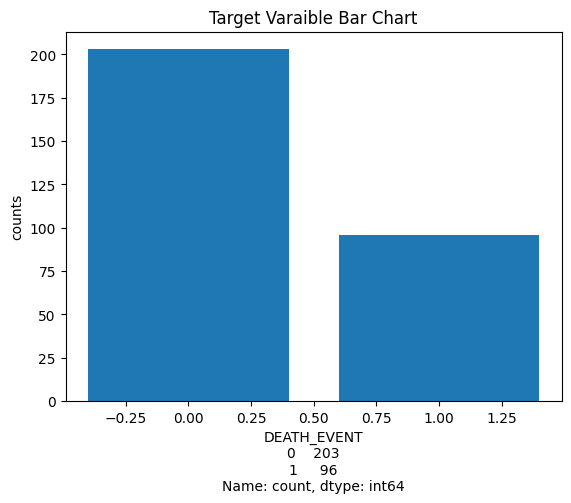

In [58]:
# 5.1 目标变量柱状图：

import matplotlib.pyplot as plt

# 目标变量分布：
target_col = 'DEATH_EVENT'

# 统计目标变量的计数：
target_counts = df[target_col].value_counts()

# 创建柱状图：
plt.bar(target_counts.index,target_counts.values)
plt.xlabel(target_counts)
plt.ylabel('counts')
plt.title('Target Varaible Bar Chart')

plt.show()

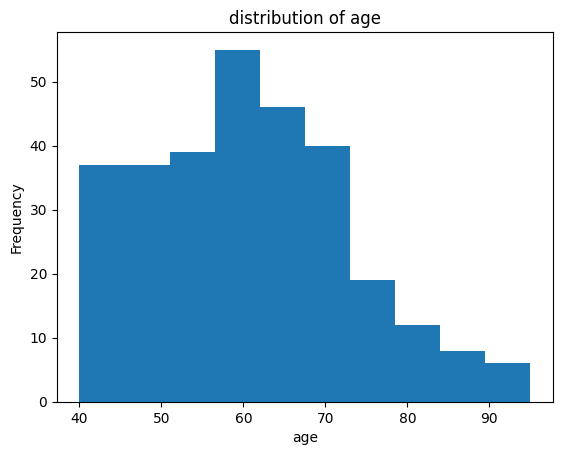

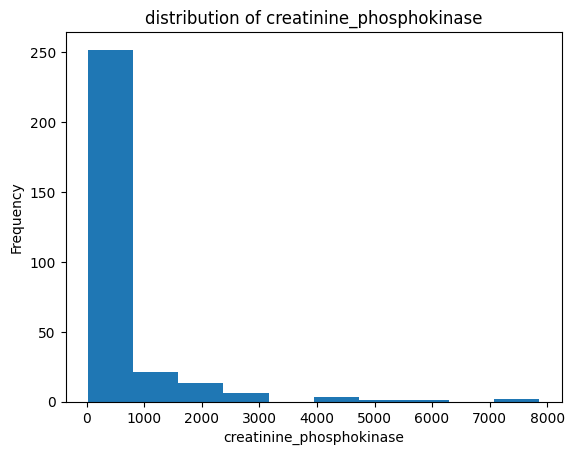

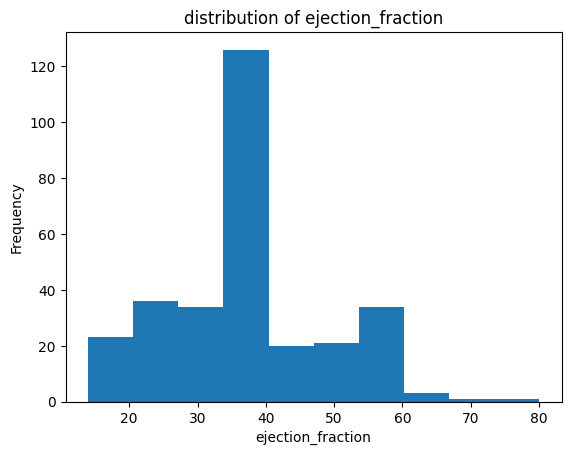

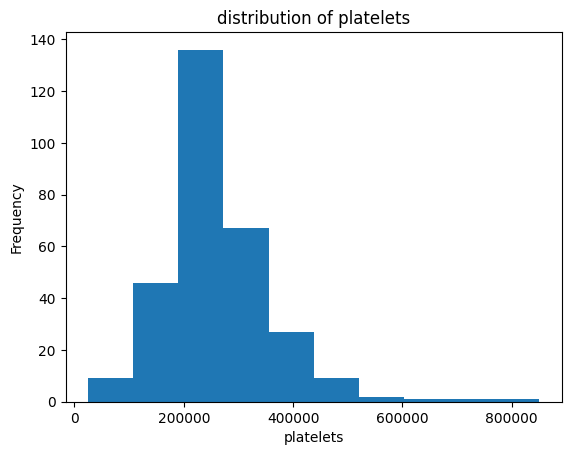

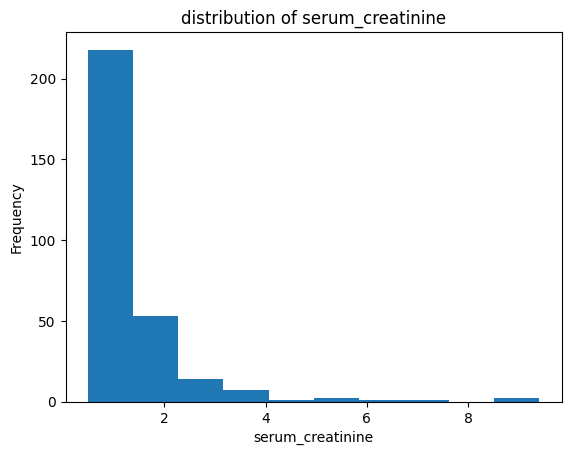

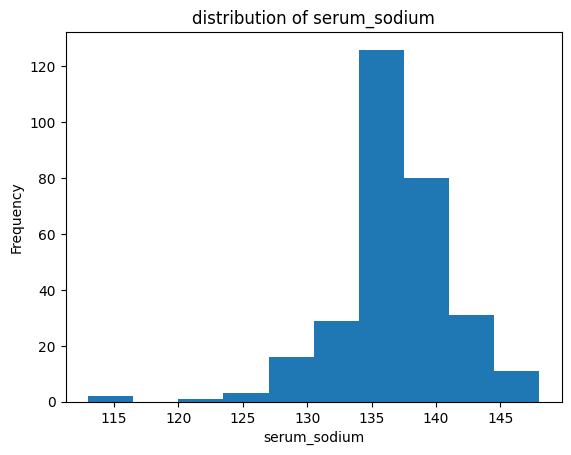

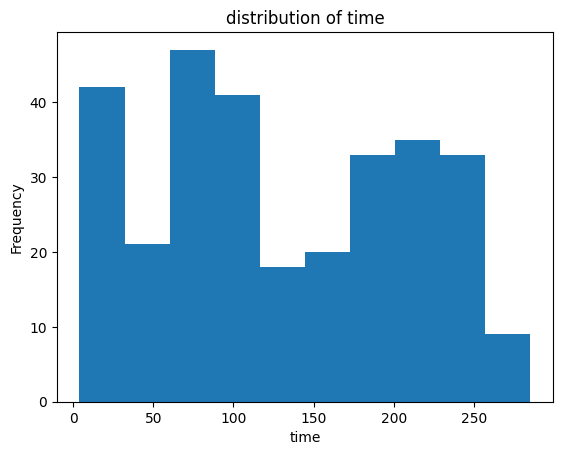

In [59]:
# 5.2 数值型特征的直方图

# 数值特征列表：

numeric_cols = ['age','creatinine_phosphokinase','ejection_fraction','platelets','serum_creatinine','serum_sodium','time']

# 创建直方图：

for col in numeric_cols:
  plt.hist(df[col],bins=10)
  plt.xlabel(col)
  plt.ylabel('Frequency')
  plt.title(f'distribution of {col}') # 在打印中将变量用中括号{}括起来则可在结果中显示，随变量不同而不同
  plt.show()

5.3 特征之间的相关热力图

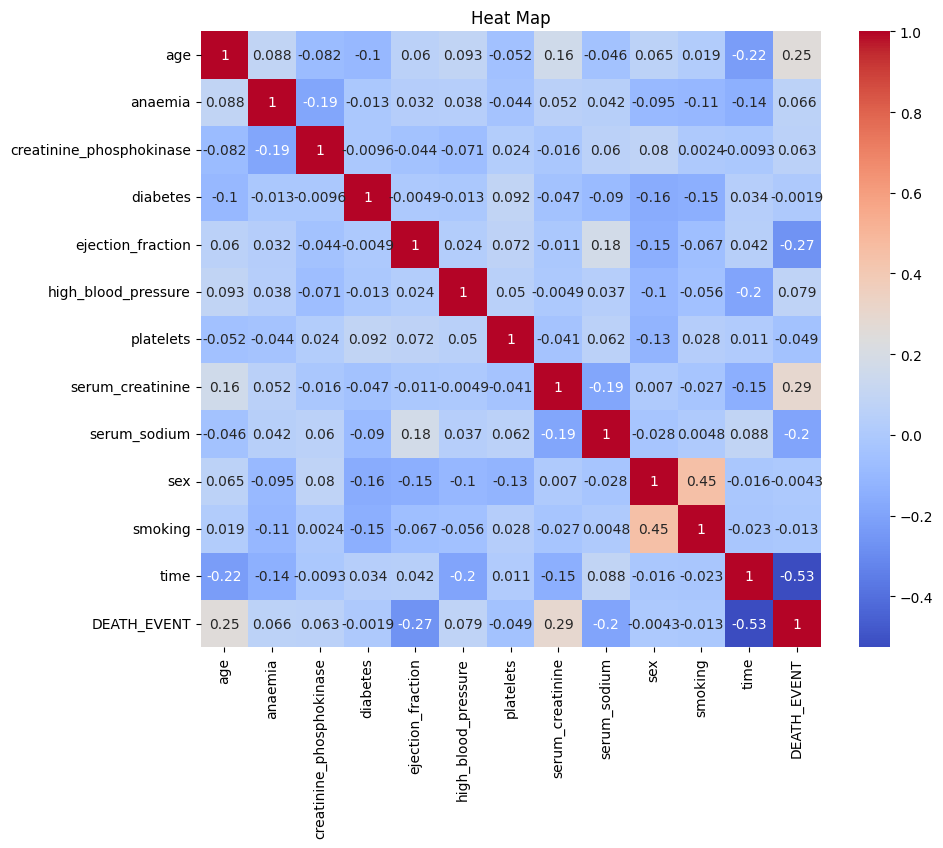

In [60]:
import seaborn as sns

# 计算特征相关系数

correlation = df.corr()

# 创建热力图

plt.figure(figsize=(10,8))
sns.heatmap(correlation,annot=True,cmap='coolwarm')
plt.title('Heat Map')
plt.show()

5. 建立预测模型（预测DEATH_EVENT和其他特征的影响）

In [67]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

# 将特征与目标变量分开：

X = df.drop('DEATH_EVENT',axis=1)
Y = df['DEATH_EVENT']

# 将数据分为训练集和测试集：

X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

# 建立逻辑回归模型：

model = LogisticRegression()

# 在训练集上训练模型：

model.fit(X_train,Y_train)

# 在测试集上进行预测：

Y_pred = model.predict(X_test)

# 计算模型的准确率、精确率、召回率、F1分数：

accuracy = accuracy_score(Y_test,Y_pred)
precision = precision_score(Y_test,Y_pred)
recall = recall_score(Y_test,Y_pred)
f1 = f1_score(Y_test,Y_pred)

# 打印模型评估指标：

print('Accuracy:',accuracy)
print('Precision:',precision)
print('Recall:',recall)
print('F1:',f1)

Accuracy: 0.8
Precision: 0.8823529411764706
Recall: 0.6
F1: 0.7142857142857143


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
